In [6]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean

# Loading and formating data

In [7]:
ctd_all = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_013_nav2.csv')
bathy_all = xr.open_dataset('/Users/Sam/Documents/Postdoc/Cruise/Cruise Data/sentry_epr_1m.nc')

In [8]:
ctd_bottom = ctd_all.loc[ctd_all['depth'] >= 2485]
ctd_bottom_geo = gpd.GeoDataFrame(ctd_bottom,geometry=gpd.points_from_xy(ctd_bottom.USBL_lon,ctd_bottom.USBL_lat),crs="EPSG:4326")

lon_min, lat_min, lon_max, lat_max = ctd_bottom_geo.total_bounds

lon_buffer = (lon_max - lon_min) * 0.07
lat_buffer = (lat_max - lat_min) * 0.07

plot_lon_min = lon_min - lon_buffer
plot_lon_max = lon_max + lon_buffer
plot_lat_min = lat_min - lat_buffer
plot_lat_max = lat_max + lat_buffer

bathy_crop = bathy_all.sel(lat=slice(plot_lat_min,plot_lat_max),lon=slice(plot_lon_min,plot_lon_max))

In [9]:
avg_latitude = (lat_min + lat_max) / 2
lon_range = (lon_max - lon_min) * np.cos(np.radians(avg_latitude))
lat_range = lat_max - lat_min

aspect_ratio = lon_range / lat_range if lat_range != 0 else 1

base_size = 10
if aspect_ratio > 1:
    figsize_temp = (base_size, base_size / aspect_ratio)
else:
    figsize_temp = (base_size * aspect_ratio, base_size)

figsize = (max(figsize_temp[0], 6), max(figsize_temp[1], 6))

# Temperature plots

This plot is plotted via time so the first records are on the bottom and the last records are on top

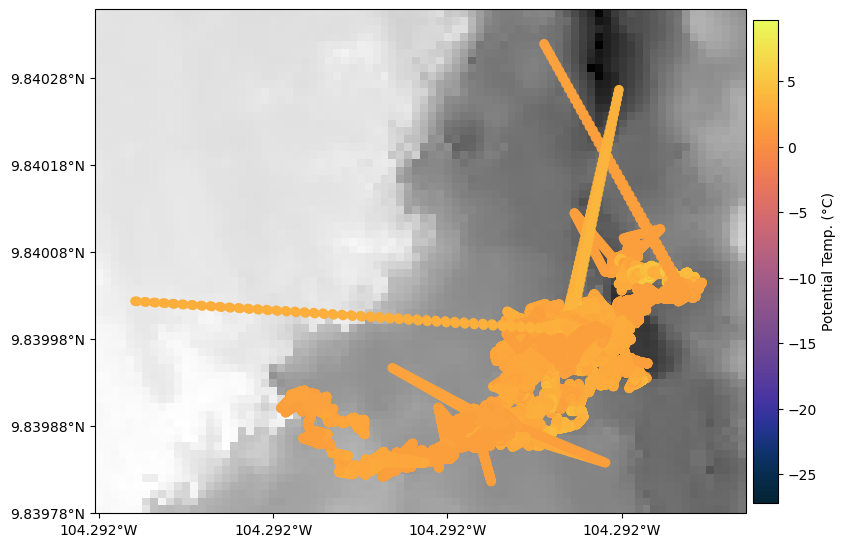

In [82]:
prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_bottom['USBL_lon'], ctd_bottom['USBL_lat'], 
                  c=ctd_bottom['pottemp'], cmap='cmo.thermal',
                 )

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Potential Temp. (°C)')

There should not be anyt lower then 0 so lets investigat as remove them 

In [83]:
ctd_sorted = ctd_bottom.sort_values('pottemp')
ctd_sorted['pottemp'].head(25)

260434   -2.715650e+01
260431   -1.831150e+01
299499   -9.990000e-29
299498   -9.990000e-29
299497   -9.990000e-29
299496   -9.990000e-29
299495   -9.990000e-29
260433   -9.990000e-29
315600   -9.990000e-29
315601   -9.990000e-29
260432   -9.990000e-29
298870    1.674100e+00
298857    1.674100e+00
298869    1.674200e+00
298566    1.674200e+00
299189    1.674200e+00
298873    1.674200e+00
298033    1.674200e+00
298877    1.674200e+00
298053    1.674200e+00
299171    1.674200e+00
298562    1.674200e+00
298296    1.674200e+00
298301    1.674200e+00
306347    1.674200e+00
Name: pottemp, dtype: float64

The plot above also obscures some of the data, so here we sort the data first to put the highest values on the bottom thus plotted last and visible

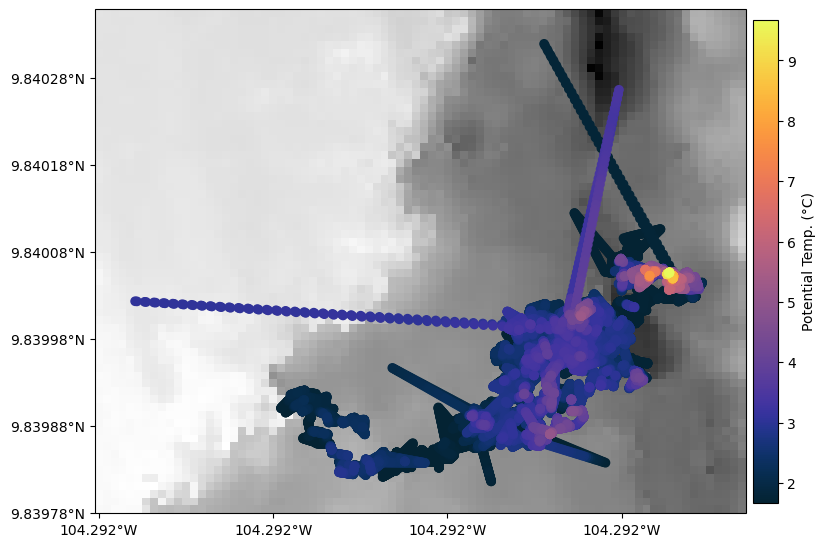

In [84]:
ctd_sorted = ctd_bottom.loc[ctd_bottom['pottemp'] > 0].sort_values('pottemp')
prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_sorted['USBL_lon'], ctd_sorted['USBL_lat'], 
                  c=ctd_sorted['pottemp'], cmap='cmo.thermal',
                  )

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Potential Temp. (°C)')

fig.savefig('CTD13_Ptemp.pdf',dpi=300)

# Salinity Plots

This plot is plotted via time so the first records are on the bottom and the last records are on top

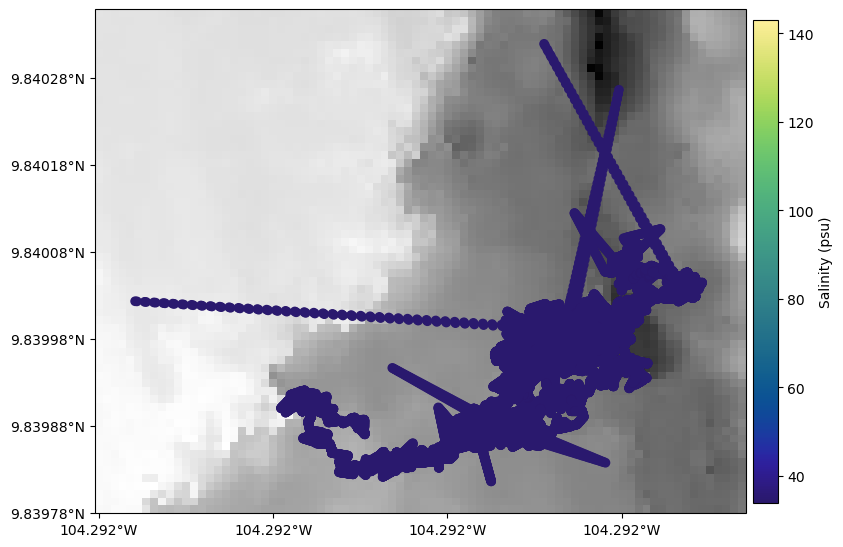

In [63]:
prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_bottom['USBL_lon'], ctd_bottom['USBL_lat'], 
                  c=ctd_bottom['salinity'], cmap='cmo.haline',
                 vmin=34,vmax=ctd_bottom['salinity'].max().round(0))

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Salinity (psu)')

The plot above obscures some of the data, so here we sort the data first to put the highest values on the bottom thus plotted last and visible 

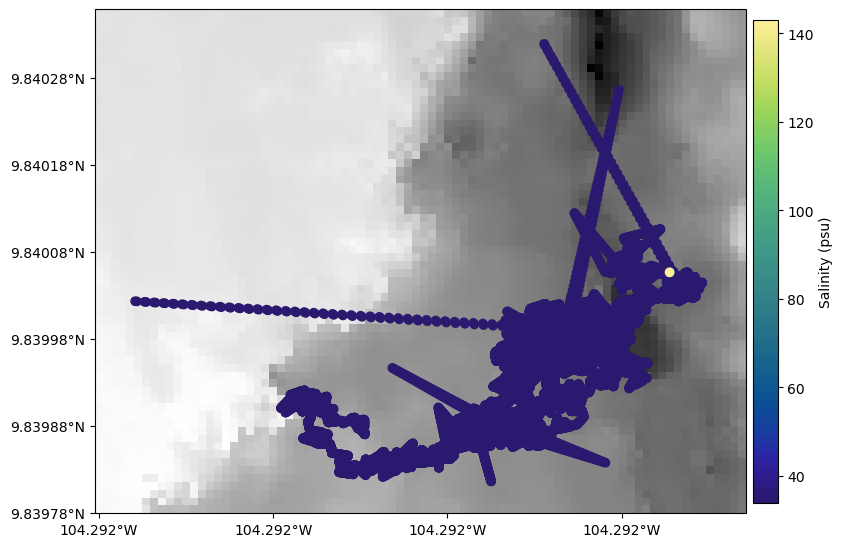

In [64]:
ctd_sorted = ctd_bottom.sort_values('salinity')
prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_sorted['USBL_lon'], ctd_sorted['USBL_lat'], 
                  c=ctd_sorted['salinity'], cmap='cmo.haline',
                 vmin=34,vmax=ctd_sorted['salinity'].max().round(0))

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Salinity (psu)')

This still looks like there is not much change lets check and see what the bottom of the table looks

In [73]:
ctd_sorted = ctd_bottom.sort_values('salinity')
ctd_sorted['salinity'].tail()

260478     35.5434
260430     35.6492
260429     35.9097
260431     90.6934
260434    142.8312
Name: salinity, dtype: float64

Thoese two high values are outliers, so remove the replot

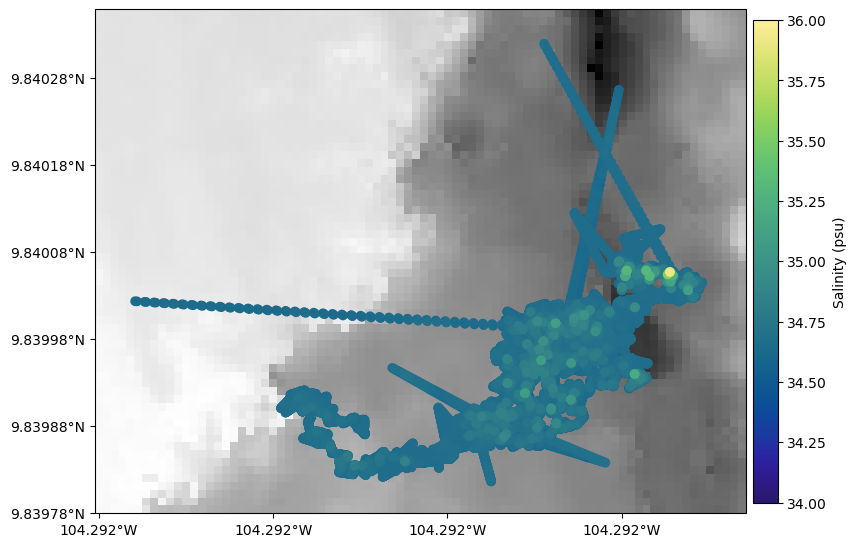

In [76]:
ctd_sorted = ctd_bottom.loc[ctd_bottom['salinity']<40].sort_values('salinity')

prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_sorted['USBL_lon'], ctd_sorted['USBL_lat'], 
                  c=ctd_sorted['salinity'], cmap='cmo.haline',
                 vmin=34,vmax=ctd_sorted['salinity'].max().round(0))

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Salinity (psu)')

fig.savefig('CTD13_sal.pdf',dpi=300)

# correlation

<Axes: xlabel='pottemp', ylabel='salinity'>

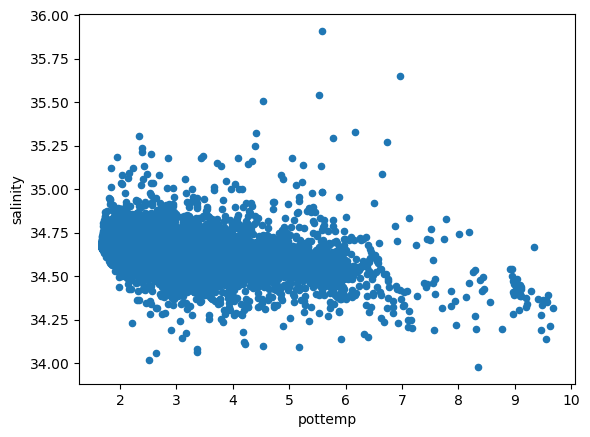

In [14]:
ctd_bottom_cor = ctd_bottom.loc[(ctd_bottom['pottemp'] > 0) & ((ctd_bottom['salinity'] < 40) & (ctd_bottom['salinity'] > 5))]

ctd_bottom_cor.plot(x='pottemp', y='salinity',kind='scatter')